## 수치 해석에서의 오차 추정 
3. Estimation of Errors in Numerical Solutions
   
    @https://en.wikipedia.org/wiki/Newton%27s_method

    @https://jspark_aadl.gitlab.io/numerical-analysis-lecture/intro.html

    @https://www.youtube.com/playlist?list=PLczEhXyH_pUfKl9SPn-9j3K7olfBj5cpl

3.0. 근(root) 구하기 및 종료 조건(estimated relative error)

- 매우 큰 행렬 system $Ax = b$를 푸는 방법
- 구간법(Bracketing methods) : 근 존재 시 항상 수렴 / 느림 (선형)
- 개방법(Open methods) : 수렴 실패 및 발산 가능성 존재 / 빠름 (초선형 ~ 2차)

In [1]:
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt

In [2]:
plt.style.use("ggplot")
plt.rcParams["figure.dpi"] = 150

---

### 3.1. 구간법(Bracketing methods)

In [3]:
class BracketingNumericalAnalysis:
    """구간법 클래스"""

    def __init__(self, a: np.array, b: np.array, tolerance: float, max_iterations = 100):
        """
        Args:
            - a, b: 해가 존재하는 구간 양 끝 데이터 (1개의 해를 포함하는 구간을 설정해야 하므로 구간 설정 중요함)
            - c: 수치적 해법 반복 중 계산되는 근사값 초기화
            - tolerance: tolerance 값보다 작으면 학습 조기 종료시키는 기준
            - max_iterations: 최대 반복 횟수 (발산 시 무한루프 방지)
            - reference: 반복횟수, c, f(c) 기록용 리스트
        """
        self.a = a
        self.b = b
        self.c = 0
        self.tolerance = tolerance
        self.max_iterations = max_iterations
        self.reference = []

    def _checkBracket(self, f):
        """전제 조건 충족 확인 메서드
        
        Logics:
            - 사잇값 정리: 함수 f(x)가 닫힌 구간 [a,b]에서 연속이고 구간 양 끝에서 함수값의 부호가 달라야 실근 c가 적어도 하나 이상 존재
        
        Args:
            - f: 근을 찾으려는 대상 함수 선언, __init__()에 저장하지 않고 메서드 호출 시 인자 남겨받는 구조
        """
        if f(self.a) * f(self.b) >= 0:
            # 구간 (a,b) 양 끝 점의 함수값의 부호가 같을 경우(곱이 양수)
            raise ValueError(
                f"f({self.a:.4f}) and f({self.b:.4f}) must have opposite signs to apply the Intermediate Value Theorem for finding a root.")
                # 해당 구간에서 해가 존재하지 않음
        # else: 
        # f(self.a) * f(self.b) < 0: 
            # return
            # np.True_

    def bisectionMethods(self, f):
        """이분법 적용 메서드
        
        Logics:
            - 구간의 중점을 다음 근사값으로 사용
        """
        self._checkBracket(f)
        a, b = self.a, self.b
        self.reference = []

        for i in range(self.max_iterations):
            self.c = (a + b) / 2.0
            fc = f(self.c)
            # 구간의 중점을 구함
            self.reference.append((
                (i + 1), # 반복 횟수
                self.c, # 수치해 근사값
                fc, # 근사값의 함수값
                (b - a) / 2.0 # 구간의 폭
            ))
            
            # 종료 조건
            if abs(fc) < self.tolerance or (b-a) / 2.0 < self.tolerance:
                # 함수값이 충분히 0에 가깝거나, 구간을 충분히 좁힌 경우
                return self.c, self.reference
                # 조건에 따라 반복을 조기 종료하고 수치해와 함수값 등 레퍼런스 히스트리 리스트 출력
            
            # 부호가 바뀐 쪽 구간을 선택해 다음 구간을 좁힘
            if f(a) * fc < 0:
                b = self.c
                # 해를 (a,c) 사이로 범위를 좁힘
                # 폐구간 끝점 b를 근사값 c로 대체
            elif fc * f(b) < 0:
                a = self.c
                # 해를 (c,b) 사이로 범위를 좁힘
                # 폐구간 첫점 a를 근사값 c로 대체
            else:
                pass

        return self.c, self.history
        # 반복을 끝나고 수치해와 함수값 등 레퍼런스 히스트리 리스트 출력  
        # Q. Compute relative error(상대오차 epsilon)
    
    def regulaFalsiMethods(self, f):
        """가위치법 적용 메서드
        
        Logics:
            - 중점 대신 (a, f(a)), (b, f(b))를 잇는 직선이 x축과 만나는 점을 사용
            - [X][AS-IS] 함수 안에서 함수 호출하는 재귀 알고리즘(recursive algorithm) 적용
        """
        self._checkBracket(f)
        a, b = self.a, self.b
        self.reference = []    

        # 구간 경계에서 해가 존재한 경우
        for i in range(self.max_iterations):
            self.c = (a * f(b) - b * f(a)) / (f(b) - f(a))
            # 구간 양 끝 점을 잇는 직선
            fc = f(self.c)
            # 그 직선과 함수의 교점, x절편 c
            self.reference.append((
                (i + 1), # 반복 횟수
                self.c, # 수치해 근사값
                fc # 근사값의 함수값
            ))

        if abs(fc) < self.tolerance:
        # 함수값이 충분히 0에 가까울 경우
            return self.c, self.history
            # 조건에 따라 반복을 조기 종료하고 수치해와 함수값 등 레퍼런스 히스트리 리스트 출력

        # 부호가 바뀐 쪽 구간을 선택해 다음 구간을 좁힘
        if f(a) * fc < 0:
            b = self.c
            # 해를 (a,c) 사이로 범위를 좁힘
            # 폐구간 끝점 b를 근사값 c로 대체
        elif fc * f(b) < 0:
            a = self.c
            # 해를 (c,b) 사이로 범위를 좁힘
            # 폐구간 첫점 a를 근사값 c로 대체
        else:
            pass

        return self.c, self.history
        # 반복을 끝나고 수치해와 함수값 등 레퍼런스 히스트리 리스트 출력

#### 3.1.1. 이분법(Bisection method)

- 해가 구간 $(a,b)$ 사이에 있을 경우 $f(c) = 0$ 해가 존재하면 $f(a) \cdot f(b) < 0$ 조건 활용하여,
- 구간 중점 $c = \frac{a+b}{2}$ 중간값을 반복적으로 구하며, 매 단계마다 오차가 $\frac{1}{2}$씩 감소
  - $f(a) \cdot f(c) < 0$이면, 해를 $(a,c)$ 사이로 범위를 좁힘
  - $f(c) \cdot f(b) < 0$이면, 해를 $(c,b)$ 사이로 범위를 좁힘

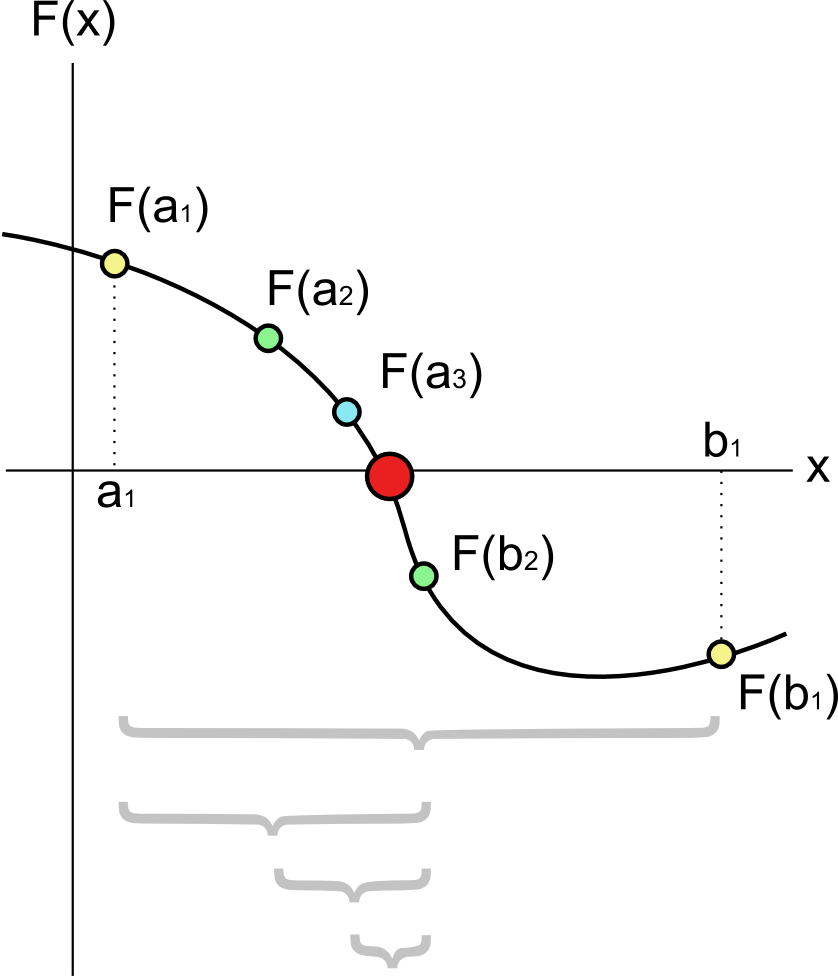

In [8]:
solver = BracketingNumericalAnalysis(
    a = -1.0, b = 1.0, tolerance = 1e-5
)

In [9]:
root, history =  solver.bisectionMethods(lambda x: x**3 - x - 2)
# ValueError: f(0.0000) and f(1.0000) must have opposite signs to apply the Intermediate Value Theorem for finding a root.

ValueError: f(-1.0000) and f(1.0000) must have opposite signs to apply the Intermediate Value Theorem for finding a root.

#### 3.1.2. 가위치법(Regula falsi method)

- 이분법보다 계산 효율을 높이기 위해 가위치(false position)를 사용
- 이 위치는 중점 대신 양 끝점을 직선으로 이었을 때 교점 사용, $\frac{f(a)}{c-a} = \frac{f(b)}{c-b}$
- a,b 두 점을 잇는 직선의 x절편 $c = \frac{af(b)-bf(a)}{f(b)-f(a)}$을 구하여 구간을 좁힘
- 즉, x절편을 새로운 근사값으로 선택하는 선형 보간법을 통해 오차를 약 $\frac{2}{3}$ 감소시킬 수 있음

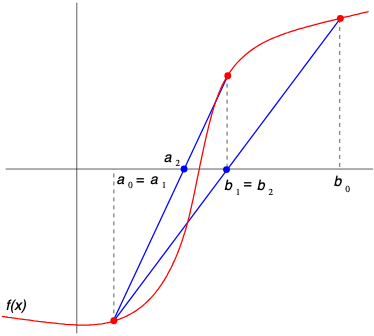

In [ ]:
root, history = solver.regulaFalsiMethods(lambda x: x**3 - x - 2)

---

### 3.2. 개방법(Open methods)

In [ ]:
class OpeningNumericalAnalysis:
    """개방법 클래스"""

    def __init__(self, a: np.array, b: np.array, tolerance: float, max_iterations = 100):
        """
        Args:
            - a, b: 해가 존재하는 구간 양 끝 데이터
            - c: 수치적 해법 반복 중 계산되는 근사값 초기화
            - tolerance: tolerance 값보다 작으면 학습 조기 종료시키는 기준
            - max_iterations: 최대 반복 횟수 (발산 시 무한루프 방지)
        """
        self.a = a
        self.b = b
        self.c = 0
        self.tolerance = tolerance
        self.max_iterations = max_iterations

    def _check(self, f):
        """전제 조건 충족 확인 메서드
        
        Logics:
            - 
        Args:
            - f: 근을 찾으려는 대상 함수 선언, __init__()에 저장하지 않고 메서드 호출 시 인자 남겨받는 구조
        """
        pass

    def newtonMethods(self, f):
        """뉴턴-랩슨법 적용 메서드
        
        Logics:
            - 
        """
        self._check(f)
        a, b = self.a, self.b


        return

    def secantMethods(self, f):
        """할선법 적용 메서드
        
        Logics:
            - 
        """
        self._check(f)
        a, b = self.a, self.b

        return

#### 3.2.1. 뉴턴법(Newton-Raphson method)

- 함수가 미분 가능한 연속 함수일 경우에,선형 근사하고 $x_{i+1}$에서 $x$축과 교점이 생기는 경우
- $0 = f(x_{i+1}) = f(x_i) + f'(x_i)(x_i+1-x_i)$
- 접선의 x절편 $x_{i+1} = x_i -\frac{f(x_i)}{f'(x_i)}$
- 수렴 속도가 이차 수렴(quadratic convergence)으로 매우 빠름
- 다만, 수렴하지 않고 local extrema 근처에서 진동(발산)할 수 있으므로 초기 추정값이 해에서 멀지 않도록 하는게 중요함

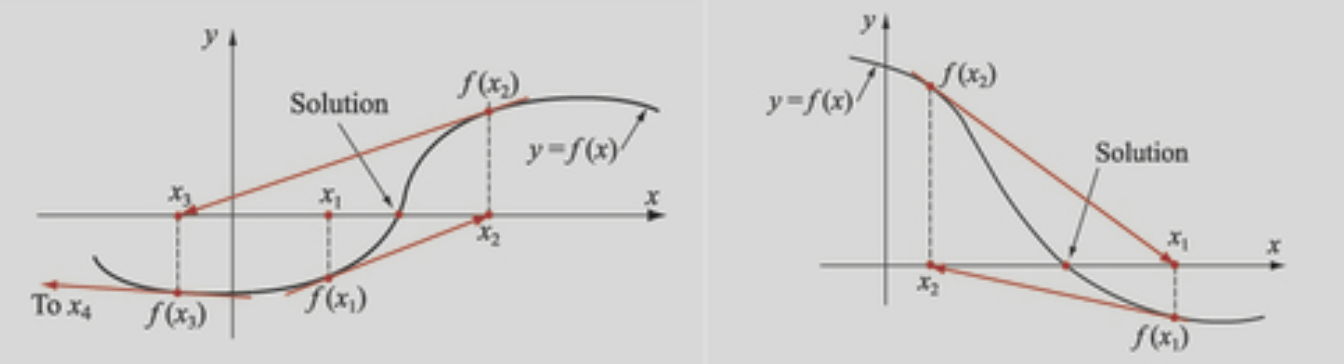

#### 3.2.2. 할선법(Secant method)

- 뉴턴법에 따라 미분하기 어려워 도함수 $f'(x)$를 직접 구하기 어려울 때, 두 점을 잇는 할선의 기울기로 대체
- $f'(x) \approx \frac{f(x_i)-f(x_{i-1})}{x_i-x_{i-1}}$ 기울기 대신 수치적으로 근사 미분값 사용
- $x_{i+1} = x_i - \frac{f(x_i)(x_i-x_{i-1})}{f(x_i)-f(x_{i-1})}$

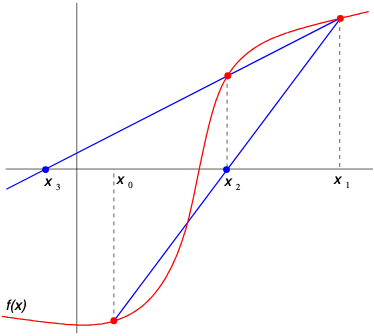

#### 3.2.3. 고정점 반복법(Fixed‐point iteration method) → 4장 전 overview

- $f(x) = 0$을 $x = g(x)$ 형태로 바꾼 후, $x_{i+1} = g(x_i)$를 반복 대입하며, $|g'(x)| < 1|$ 조건에서 수렴 (also called “Lipschitz continuous”)
- 근사 상대 오차(Estimated relative error)를 통해 반복법의 수렴 여부를 판단하기 위한 이전 단계 및 현재 단계의 해를 비교함

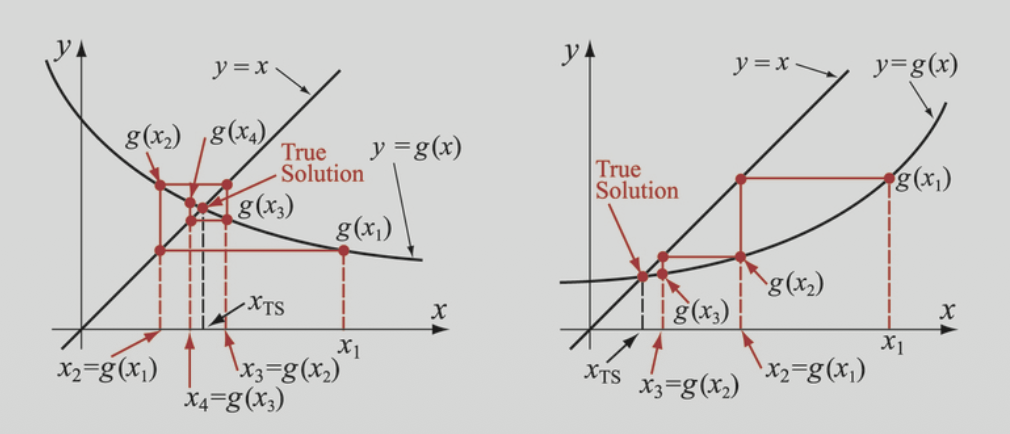